In [5]:
import os
import cv2
import supervision as sv
import ultralytics
from pathlib import Path
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm  # For progress bar
from ultralytics import YOLO


# Change these paths and run all cells
model = YOLO("/home/omtalmo/Olaf_TTK4265/TDT4265-Snow-pole-detection/runs_yolov12/runs/detect/train3/weights/best.pt")
model2 = YOLO("/home/omtalmo/Olaf_TTK4265/TDT4265-Snow-pole-detection/yolov12/yolov12/runs/detect/train/weights/best.pt")
dataset_path = "/home/omtalmo/Olaf_TTK4265/Poles/rgb"
output_dir = "/home/omtalmo/Olaf_TTK4265/TDT4265-Snow-pole-detection/results"

# Find test images with case-insensitive extension matching
test_image_dir = f"{dataset_path}/images/test"
test_images = []
for img in os.listdir(test_image_dir):
    if img.upper().endswith('.PNG') or img.lower().endswith(('.png', '.jpg', '.jpeg')):
        test_images.append(os.path.join(test_image_dir, img))


In [2]:
import time
import torch
import numpy as np
from tqdm.notebook import tqdm

def benchmark_model(model, test_images, num_runs=5, warm_up=2):
    """
    Benchmark YOLOv12 model inference speed.
    
    Args:
        model: YOLO model
        test_images: List of image paths to test
        num_runs: Number of runs to average performance over
        warm_up: Number of warm-up runs to exclude from timing
    
    Returns:
        DataFrame with performance metrics for each image
    """
    import pandas as pd
    
    # Results storage
    results = []
    
    # Ensure CUDA is properly warmed up if available
    device = next(model.parameters()).device
    if device.type == 'cuda':
        torch.cuda.synchronize()
    
    print(f"Running benchmark on {len(test_images)} images ({num_runs} runs each, {warm_up} warm-up runs)...")
    
    for image_idx, image_path in enumerate(tqdm(test_images)):
        image_name = Path(image_path).name
        
        # Load and prepare the image
        image = cv2.imread(image_path)
        if image is None:
            print(f"Warning: Could not load {image_path}")
            continue
        
        # Warm-up runs
        for _ in range(warm_up):
            _ = model(image)
        
        # Actual timing runs
        times = []
        box_counts = []
        inference_times = []
        postprocessing_times = []
        total_boxes_processed = []
        
        for run in range(num_runs):
            # Start timing
            start_time = time.time()
            
            # Track internal metrics
            torch.cuda.synchronize() if device.type == 'cuda' else None
            inference_start = time.time()
            
            # Run detection
            with torch.no_grad():
                preds = model(image, verbose=False)
            
            # Synchronize before timing to ensure GPU operations complete
            torch.cuda.synchronize() if device.type == 'cuda' else None
            inference_end = time.time()
            
            # Get detections with NMS (this is the post-processing step)
            postprocessing_start = time.time()
            detections = sv.Detections.from_ultralytics(preds[0])
            postprocessing_end = time.time()
            
            # End timing
            end_time = time.time()
            
            # Record metrics
            total_time = end_time - start_time
            inference_time = inference_end - inference_start
            postprocessing_time = postprocessing_end - postprocessing_start
            
            # Count boxes
            boxes_before_nms = len(preds[0].boxes)
            boxes_after_nms = len(detections)
            
            times.append(total_time)
            inference_times.append(inference_time)
            postprocessing_times.append(postprocessing_time)
            box_counts.append(boxes_after_nms)
            total_boxes_processed.append(boxes_before_nms)
        
        # Calculate statistics
        avg_time = np.mean(times)
        std_time = np.std(times)
        avg_inference = np.mean(inference_times)
        avg_postprocessing = np.mean(postprocessing_times)
        avg_boxes = np.mean(box_counts)
        avg_boxes_processed = np.mean(total_boxes_processed)
        fps = 1.0 / avg_time if avg_time > 0 else 0
        
        # Store results
        results.append({
            'image': image_name,
            'avg_time_ms': avg_time * 1000,
            'std_time_ms': std_time * 1000,
            'inference_ms': avg_inference * 1000,
            'postprocessing_ms': avg_postprocessing * 1000,
            'fps': fps,
            'boxes_detected': avg_boxes,
            'boxes_processed': avg_boxes_processed
        })
        
    # Convert to DataFrame for easy analysis
    results_df = pd.DataFrame(results)
    
    # Print summary
    print("\nPerformance Summary:")
    print(f"Average FPS: {results_df['fps'].mean():.2f}")
    print(f"Average total time: {results_df['avg_time_ms'].mean():.2f} ms")
    print(f"Average inference time: {results_df['inference_ms'].mean():.2f} ms")
    print(f"Average postprocessing time: {results_df['postprocessing_ms'].mean():.2f} ms")
    print(f"Average number of boxes processed: {results_df['boxes_processed'].mean():.2f}")
    print(f"Average number of final detections: {results_df['boxes_detected'].mean():.2f}")
    
    return results_df

In [ ]:
benchmark_model(model, test_images, num_runs=5, warm_up=2)

Running benchmark on 197 images (5 runs each, 2 warm-up runs)...


  0%|          | 0/197 [00:00<?, ?it/s]


0: 96x640 (no detections), 28.3ms
Speed: 1.5ms preprocess, 28.3ms inference, 21.1ms postprocess per image at shape (1, 3, 96, 640)

0: 96x640 (no detections), 4.9ms
Speed: 0.4ms preprocess, 4.9ms inference, 0.2ms postprocess per image at shape (1, 3, 96, 640)

Performance Summary:
Average FPS: 217.03
Average total time: 4.61 ms
Average inference time: 4.58 ms
Average postprocessing time: 0.04 ms
Average number of boxes processed: 0.02
Average number of final detections: 0.02


,image,avg_time_ms,std_time_ms,inference_ms,postprocessing_ms,fps,boxes_detected,boxes_processed
0,image_1638.png,4.737520,0.420576,4.695415,0.041103,211.080893,0.0,0.0
1,image_226.png,4.561281,0.057591,4.525471,0.034809,219.236648,0.0,0.0
2,image_1869.png,4.514837,0.037748,4.479647,0.034237,221.491926,0.0,0.0
3,image_1750.png,4.564810,0.060266,4.527521,0.036383,219.067178,0.0,0.0
4,image_440.png,4.533958,0.066965,4.497957,0.035095,220.557823,0.0,0.0
...,...,...,...,...,...,...,...,...
192,image_898.png,4.610348,0.048750,4.572439,0.036812,216.903378,0.0,0.0
193,image_269.png,4.642630,0.110913,4.606915,0.034857,215.395171,0.0,0.0
194,image_2096.png,4.563284,0.026715,4.527044,0.035334,219.140430,0.0,0.0
195,image_62.png,4.614496,0.063126,4.578161,0.035381,216.708379,0.0,0.0


In [3]:
# Function to create a performance comparison between original and optimized models
def compare_model_performance(original_model, optimized_model, test_images, num_images=5, runs=3):
    """Compare performance between the original model and the optimized model"""
    # Select a subset of test images for benchmarking
    benchmark_images = test_images[:num_images]
    
    print("Benchmarking original model...")
    original_results = benchmark_model(original_model, benchmark_images, num_runs=runs)
    
    print("\nBenchmarking optimized model...")
    optimized_results = benchmark_model(optimized_model, benchmark_images, num_runs=runs)
    
    # Create comparison visualization
    plt.figure(figsize=(12, 8))
    
    # FPS comparison
    plt.subplot(2, 2, 1)
    plt.bar(['Original', 'Optimized'], 
            [original_results['fps'].mean(), optimized_results['fps'].mean()], 
            color=['blue', 'green'])
    plt.title('Average FPS')
    plt.ylabel('Frames Per Second')
    
    # Timing breakdown
    plt.subplot(2, 2, 2)
    x = np.arange(2)
    width = 0.35
    plt.bar(x - width/2, 
            [original_results['inference_ms'].mean(), optimized_results['inference_ms'].mean()], 
            width, label='Inference')
    plt.bar(x + width/2, 
            [original_results['postprocessing_ms'].mean(), optimized_results['postprocessing_ms'].mean()], 
            width, label='Postprocessing')
    plt.xticks(x, ['Original', 'Optimized'])
    plt.title('Time Breakdown (ms)')
    plt.ylabel('Time (ms)')
    plt.legend()
    
    # Boxes processed
    plt.subplot(2, 2, 3)
    plt.bar(['Original', 'Optimized'], 
            [original_results['boxes_processed'].mean(), optimized_results['boxes_processed'].mean()], 
            color=['blue', 'green'])
    plt.title('Average Boxes Processed')
    plt.ylabel('Number of Boxes')
    
    # Final detections
    plt.subplot(2, 2, 4)
    plt.bar(['Original', 'Optimized'], 
            [original_results['boxes_detected'].mean(), optimized_results['boxes_detected'].mean()], 
            color=['blue', 'green'])
    plt.title('Average Final Detections')
    plt.ylabel('Number of Boxes')
    
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, 'model_performance_comparison.png'))
    plt.show()
    
    # Calculate percentage improvements
    fps_improvement = (optimized_results['fps'].mean() / original_results['fps'].mean() - 1) * 100
    time_improvement = (1 - optimized_results['avg_time_ms'].mean() / original_results['avg_time_ms'].mean()) * 100
    box_reduction = (1 - optimized_results['boxes_processed'].mean() / original_results['boxes_processed'].mean()) * 100
    
    print(f"\nPerformance Improvements:")
    print(f"FPS increase: {fps_improvement:.1f}%")
    print(f"Total time reduction: {time_improvement:.1f}%")
    print(f"Box processing reduction: {box_reduction:.1f}%")
    
    return original_results, optimized_results

Benchmarking original model...
Running benchmark on 5 images (3 runs each, 2 warm-up runs)...


  0%|          | 0/5 [00:00<?, ?it/s]


0: 416x640 2 poles, 29.0ms
Speed: 1.6ms preprocess, 29.0ms inference, 84.1ms postprocess per image at shape (1, 3, 416, 640)

0: 416x640 2 poles, 5.2ms
Speed: 1.5ms preprocess, 5.2ms inference, 0.5ms postprocess per image at shape (1, 3, 416, 640)

Performance Summary:
Average FPS: 182.63
Average total time: 5.48 ms
Average inference time: 5.41 ms
Average postprocessing time: 0.07 ms
Average number of boxes processed: 1.00
Average number of final detections: 1.00

Benchmarking optimized model...
Running benchmark on 5 images (3 runs each, 2 warm-up runs)...


  0%|          | 0/5 [00:00<?, ?it/s]


0: 416x640 2 poles, 4.5ms
Speed: 0.9ms preprocess, 4.5ms inference, 0.5ms postprocess per image at shape (1, 3, 416, 640)

0: 416x640 2 poles, 4.3ms
Speed: 0.9ms preprocess, 4.3ms inference, 0.4ms postprocess per image at shape (1, 3, 416, 640)

Performance Summary:
Average FPS: 181.11
Average total time: 5.53 ms
Average inference time: 5.46 ms
Average postprocessing time: 0.06 ms
Average number of boxes processed: 0.80
Average number of final detections: 0.80


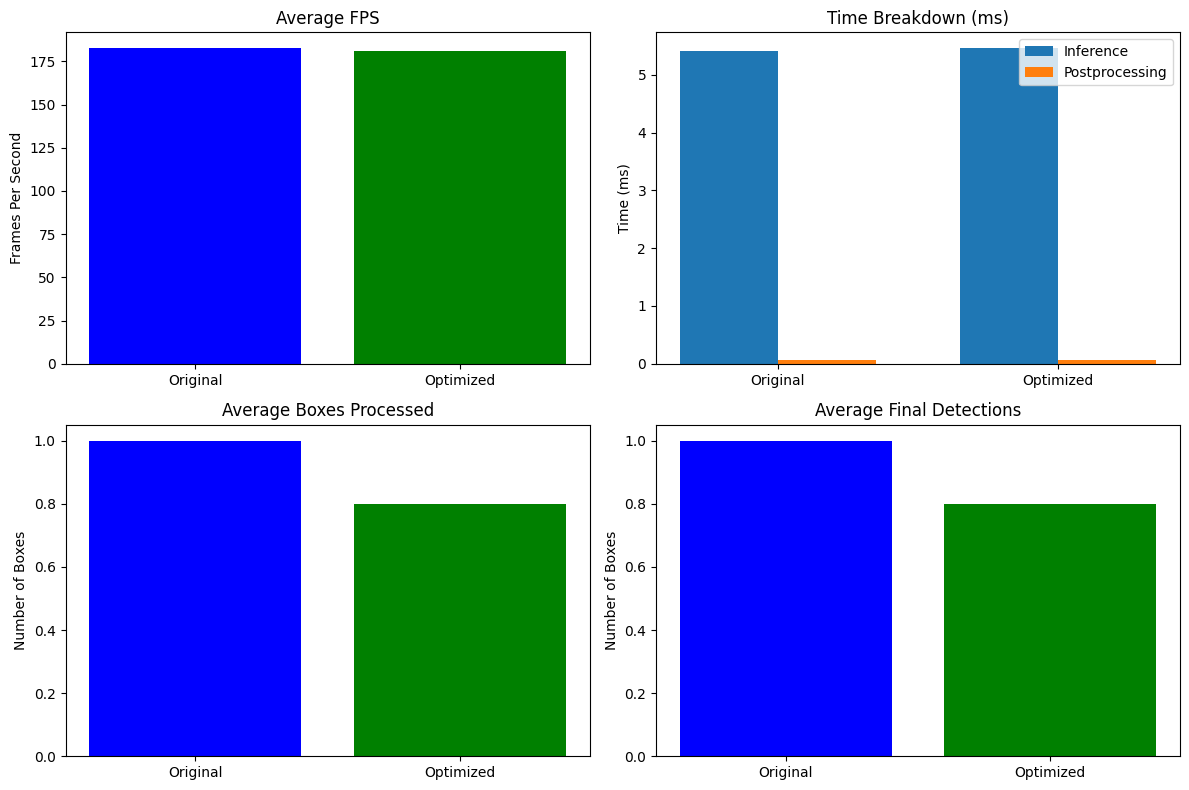


Performance Improvements:
FPS increase: -0.8%
Total time reduction: -0.8%
Box processing reduction: 20.0%


(              image  avg_time_ms  std_time_ms  inference_ms  \
 0  frame_000005.PNG     5.871932     0.293776      5.755742   
 1  frame_000510.PNG     5.489429     0.140458      5.442460   
 2  frame_004760.PNG     5.310456     0.047218      5.243063   
 3  frame_000570.PNG     5.397240     0.093248      5.336841   
 4  frame_000315.PNG     5.345345     0.144563      5.287250   
 
    postprocessing_ms         fps  boxes_detected  boxes_processed  
 0           0.114123  170.301708             2.0              2.0  
 1           0.046094  182.168315             0.0              0.0  
 2           0.066121  188.307748             1.0              1.0  
 3           0.059207  185.279873             1.0              1.0  
 4           0.057300  187.078680             1.0              1.0  ,
               image  avg_time_ms  std_time_ms  inference_ms  \
 0  frame_000005.PNG     5.670071     0.131363      5.573750   
 1  frame_000510.PNG     5.308072     0.031941      5.267541   
 2  fra

In [6]:
compare_model_performance(model, model2, test_images, num_images=5, runs=3)